In [1]:
!pip install numpy pandas scikit-fuzzy matplotlib networkx requests 

In [2]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#Load the cleaned dataset
data = pd.read_csv('./winequality-red (2).csv')

# Display first 30% of the dataset
percentage = 0.3
data[:int(len(data) * percentage)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.7,0.560,0.08,2.50,0.114,14.0,46.0,0.99710,3.24,0.66,9.60,6
1,7.8,0.500,0.17,1.60,0.082,21.0,102.0,0.99600,3.39,0.48,9.50,5
2,10.7,0.670,0.22,2.70,0.107,17.0,34.0,1.00040,3.28,0.98,9.90,6
3,8.5,0.460,0.31,2.25,0.078,32.0,58.0,0.99800,3.33,0.54,9.80,5
4,6.7,0.460,0.24,1.70,0.077,18.0,34.0,0.99480,3.39,0.60,10.60,6
5,7.2,0.410,0.30,2.10,0.083,35.0,72.0,0.99700,3.44,0.52,9.40,5
6,7.7,0.540,0.26,1.90,0.089,23.0,147.0,0.99636,3.26,0.59,9.70,5
7,7.0,0.780,0.08,2.00,0.093,10.0,19.0,0.99560,3.40,0.47,10.00,5
8,8.2,0.390,0.38,1.50,0.058,10.0,29.0,0.99620,3.26,0.74,9.80,5
9,5.8,0.610,0.11,1.80,0.066,18.0,28.0,0.99483,3.55,0.66,10.90,6


In [4]:
np.random.seed(42) # for reproducibility
n_samples = 200
data = pd.DataFrame({
    'alcohol': np.clip(np.random.normal(10.5, 1.2, n_samples), 8.5, 14.5), # ~8.5 to 14.5
    'volatile acidity': np.clip(np.random.normal(0.5, 0.2, n_samples), 0.1, 1.5), # ~0.1 to 1.5
    'sulphates': np.clip(np.random.normal(0.65, 0.15, n_samples), 0.3, 1.2), # ~0.3 to 1.2
    'quality': np.random.randint(4, 9, n_samples) # Original quality score (4 to 8)
})
print("Simulated Data Head:")
print(data[['alcohol', 'volatile acidity', 'sulphates', 'quality']].head())
print("-" * 50)

Simulated Data Head:
     alcohol  volatile acidity  sulphates  quality
0  11.096057          0.571557   0.410836        7
1  10.334083          0.612157   0.560094        7
2  11.277226          0.716610   0.650787        8
3  12.327636          0.710760   0.657047        5
4  10.219016          0.224466   0.582490        6
--------------------------------------------------


In [5]:
min_alc = data['alcohol'].min()
max_alc = data['alcohol'].max()
min_va = data['volatile acidity'].min()
max_va = data['volatile acidity'].max()
min_sul = data['sulphates'].min()
max_sul = data['sulphates'].max()

In [6]:
alcohol = ctrl.Antecedent(np.arange(min_alc, max_alc + 0.1, 0.1), 'alcohol')
volatile_acidity = ctrl.Antecedent(np.arange(min_va, max_va + 0.01, 0.01), 'volatile_acidity')
sulphates = ctrl.Antecedent(np.arange(min_sul, max_sul + 0.01, 0.01), 'sulphates')

fuzzy_quality = ctrl.Consequent(np.arange(0, 101, 1), 'fuzzy_quality')

In [7]:
# Fungsi Keanggotaan: Alcohol
# Range: ~8.5 - 14.5
# Fungsi Keanggotaan: Alcohol (otomatis menyesuaikan range data)
alcohol['low'] = fuzz.trimf(alcohol.universe, [min_alc, min_alc, (min_alc + max_alc) / 2 - 1])
alcohol['medium'] = fuzz.trimf(alcohol.universe, [min_alc + 1, (min_alc + max_alc) / 2, max_alc - 1])
alcohol['high'] = fuzz.trimf(alcohol.universe, [(min_alc + max_alc) / 2, max_alc, max_alc])


# Fungsi Keanggotaan: Volatile Acidity (Asam Volatil - Lebih rendah lebih baik)
# Range: ~0.1 - 1.5
volatile_acidity['low'] = fuzz.trimf(volatile_acidity.universe, [min_va, min_va, 0.4])
volatile_acidity['normal'] = fuzz.trimf(volatile_acidity.universe, [0.3, 0.6, 0.9])
volatile_acidity['high'] = fuzz.trimf(volatile_acidity.universe, [0.7, max_va, max_va])

# Fungsi Keanggotaan: Sulphates (Sulfat - Lebih tinggi lebih baik, dalam batas)
# Range: ~0.3 - 1.2
sulphates['low'] = fuzz.trimf(sulphates.universe, [min_sul, min_sul, 0.5])
sulphates['medium'] = fuzz.trimf(sulphates.universe, [0.4, 0.7, 1.0])
sulphates['high'] = fuzz.trimf(sulphates.universe, [0.8, max_sul, max_sul])

# Fungsi Keanggotaan: Fuzzy Quality (Output)
# Range: 0 - 100
fuzzy_quality['poor'] = fuzz.trimf(fuzzy_quality.universe, [0, 0, 50]) # Sedikit diperlebar
fuzzy_quality['average'] = fuzz.trimf(fuzzy_quality.universe, [30, 60, 90]) # Diperlebar
fuzzy_quality['good'] = fuzz.trimf(fuzzy_quality.universe, [80, 100, 100]) # Dimulai sedikit lebih lambat

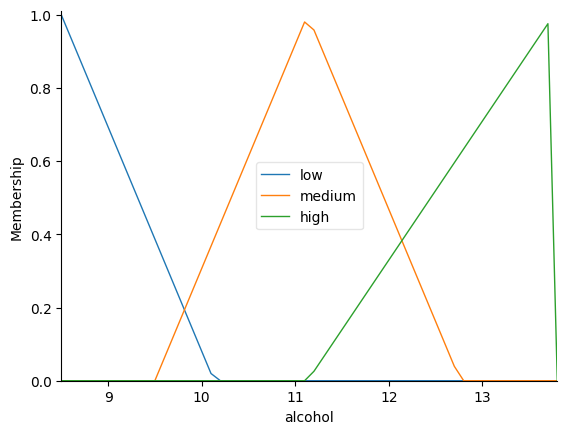

In [18]:
%matplotlib inline
alcohol.view()
plt.show()

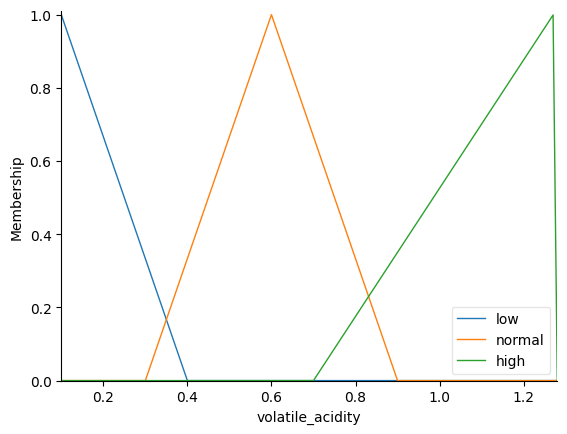

In [20]:
%matplotlib inline
volatile_acidity.view()
plt.show()

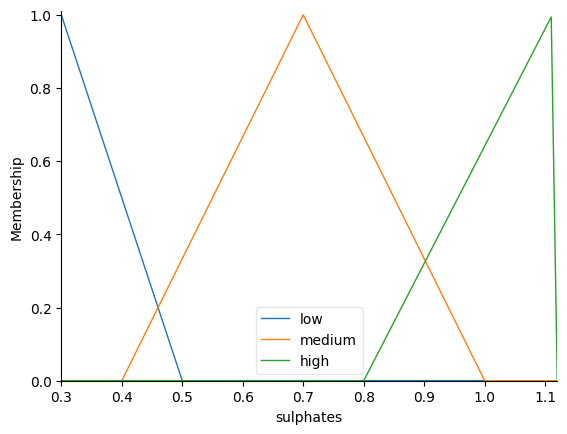

In [22]:
%matplotlib inline
sulphates.view()
plt.show()

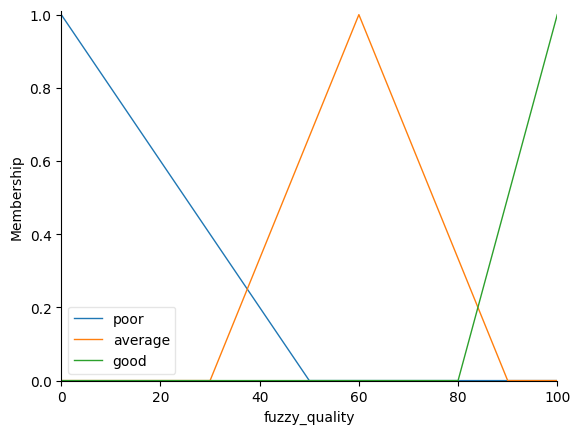

In [23]:
%matplotlib inline
fuzzy_quality.view()
plt.show()

In [10]:
rule1 = ctrl.Rule(alcohol['high'] & volatile_acidity['low'] & sulphates['medium'], fuzzy_quality['good'])
rule2 = ctrl.Rule(alcohol['medium'] & volatile_acidity['normal'] & sulphates['medium'], fuzzy_quality['average'])
rule3 = ctrl.Rule(alcohol['low'] | volatile_acidity['high'], fuzzy_quality['poor'])
rule4 = ctrl.Rule(alcohol['high'] & volatile_acidity['high'], fuzzy_quality['average'])
rule5 = ctrl.Rule(sulphates['high'] & alcohol['high'], fuzzy_quality['good'])
rule6 = ctrl.Rule(volatile_acidity['low'] & alcohol['medium'], fuzzy_quality['average'])

rule_default = ctrl.Rule(alcohol['medium'] & volatile_acidity['normal'] & sulphates['medium'], fuzzy_quality['average'])

In [11]:
# Build fuzzy system
fuzzy_control_system = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule_default
])


def compute_fuzzy_quality(row):
    quality_simulation = ctrl.ControlSystemSimulation(fuzzy_control_system)
    try:
        # Clip input agar tidak keluar range
        alc_value = np.clip(row['alcohol'], alcohol.universe.min(), alcohol.universe.max())
        va_value = np.clip(row['volatile acidity'], volatile_acidity.universe.min(), volatile_acidity.universe.max())
        sul_value = np.clip(row['sulphates'], sulphates.universe.min(), sulphates.universe.max())

        quality_simulation.input['alcohol'] = alc_value
        quality_simulation.input['volatile_acidity'] = va_value
        quality_simulation.input['sulphates'] = sul_value

        quality_simulation.compute()

        # 🔹 Gunakan .get() supaya tidak error kalau output kosong
        return quality_simulation.output.get('fuzzy_quality', np.nan)

    except Exception as ex:
        # Gak usah print error, cukup kembalikan NaN
        return np.nan

In [12]:
# Terapkan model fuzzy logic ke dataset
data['Fuzzy_Quality_Score'] = data.apply(compute_fuzzy_quality, axis=1)
# Tambahan setelah kolom Fuzzy_Quality_Score dibuat
def categorize_quality(score):
    if pd.isna(score):
        return 'Unknown'
    elif score < 50:
        return 'Poor'
    elif score < 75:
        return 'Average'
    else:
        return 'Good'

data['Kategori_Kualitas_Fuzzy'] = data['Fuzzy_Quality_Score'].apply(categorize_quality)

print(data[['alcohol', 'volatile acidity', 'sulphates', 'quality', 'Fuzzy_Quality_Score', 'Kategori_Kualitas_Fuzzy']].head(10))

print("-" * 50)
print("Penambahan Kolom Insight Baru:")
print(data[['alcohol', 'volatile acidity', 'sulphates', 'quality', 'Fuzzy_Quality_Score']].head(10))
print("-" * 50)

     alcohol  volatile acidity  sulphates  quality  Fuzzy_Quality_Score  \
0  11.096057          0.571557   0.410836        7            60.000000   
1  10.334083          0.612157   0.560094        7            60.000000   
2  11.277226          0.716610   0.650787        8            58.492362   
3  12.327636          0.710760   0.657047        5            58.222093   
4  10.219016          0.224466   0.582490        6            60.000000   
5  10.219036          0.312435   0.743427        6            60.000000   
6  12.395055          0.603007   0.489857        6            60.000000   
7  11.420922          0.602757   0.628643        7            60.000000   
8   9.936631          0.603010   0.668044        7            50.518071   
9  11.151072          1.270546   0.727166        5            17.819596   

  Kategori_Kualitas_Fuzzy  
0                 Average  
1                 Average  
2                 Average  
3                 Average  
4                 Average  
5     

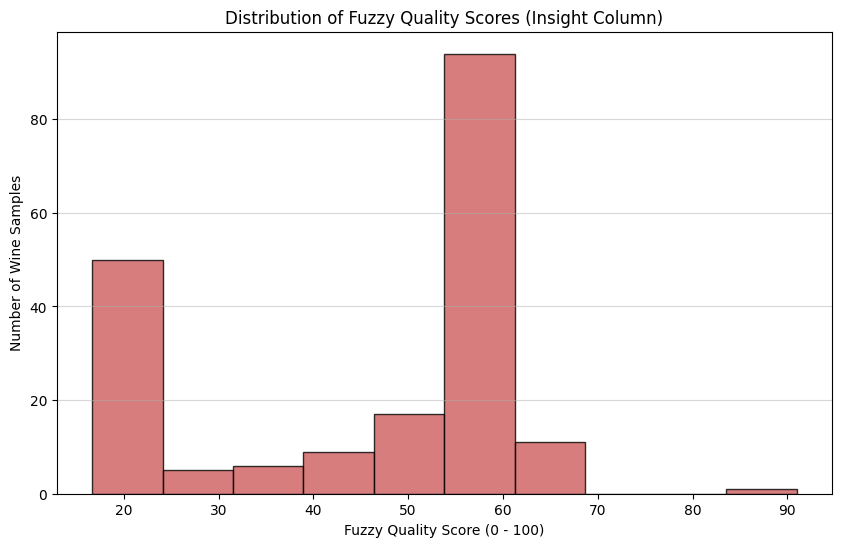

Hasil inferensi telah diekspor ke: fuzzy_wine_quality_results.csv


In [13]:
plt.figure(figsize=(10,6))
plt.hist(data['Fuzzy_Quality_Score'].dropna(), bins=10, color='indianred', edgecolor='black', alpha=0.8)
plt.title('Distribution of Fuzzy Quality Scores (Insight Column)')
plt.xlabel('Fuzzy Quality Score (0 - 100)')
plt.ylabel('Number of Wine Samples')
plt.grid(axis='y', alpha=0.5)
plt.show()

output_filename = 'fuzzy_wine_quality_results.csv'
data.to_csv(output_filename, index=False)
print(f"Hasil inferensi telah diekspor ke: {output_filename}")
